In [22]:
import pyvene as pv
import pandas as pd
import numpy as np
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
import datasets
import torch
import random
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from datasets import Dataset, DatasetDict

%config InlineBackend.figure_formats = ['svg']
from plotnine import (
    ggplot,
    geom_tile,
    aes,
    facet_wrap,
    theme,
    element_text,
    geom_bar,
    geom_hline,
    scale_y_discrete,
    geom_line,
    geom_point,
    geom_text,
    ggtitle, xlab, ylab, 
    ggsave
)
from plotnine.scales import scale_y_reverse, scale_fill_cmap
from tqdm import tqdm
from collections import namedtuple

### Models

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [30]:
def probing_config(intervention_site, layer, max_units):
    """Generate intervention config."""

    # init
    config = pv.IntervenableConfig([{
        "layer": layer,
        "component": intervention_site,
        "max_number_of_units": max_units, # from args
        "intervention_type": pv.CollectIntervention,
    }])
    return config

In [4]:
def get_model_and_tokenizer(version: int = 70):
    # version: Literal[70, 160, 410] = 70
    model_name = f"EleutherAI/pythia-{version}m"
    # model_name = 'gpt2-xl'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_name, revision="main", torch_dtype=torch.float32).to(device)
    return model, tokenizer

In [5]:
gpt70, tokenizer70 = get_model_and_tokenizer(70)
gpt160, tokenizer160 = get_model_and_tokenizer(160)
gpt410, tokenizer410 = get_model_and_tokenizer(410)

### Datasets

In [6]:
motivations = datasets.load_dataset("tasksource/babi_nli", 'agents-motivations')
colors = datasets.load_dataset("tasksource/babi_nli", 'basic-induction')

In [7]:
motivations["train"][0], colors["train"][0]

({'premise': 'Sumit is bored. Jason is bored. Yann is thirsty. Jason went to the garden. Jason grabbed the football there. Yann moved to the kitchen. Yann got the milk there. Sumit moved to the garden.',
  'hypothesis': 'Sumit went to the garden because she was bored.',
  'label': 1,
  'idx': 0},
 {'premise': 'Lily is a rhino. Lily is white. Bernhard is a swan. Brian is a lion. Bernhard is white. Julius is a rhino. Julius is white. Brian is yellow. Greg is a lion.',
  'hypothesis': 'Greg is yellow.',
  'label': 1,
  'idx': 0})

In [8]:
def create_dataset(dataset: Dataset, filter_labels=None):
    dataset = dataset.filter(lambda x: x['label'] == 1)
    text = np.array([f"{x['premise']} {x['hypothesis']}".rsplit(".", 1)[0].rsplit(" ", 1) for x in dataset])
    label = text[:, 1]
    input = text[:, 0]

    if filter_labels:
        mask = np.isin(label, filter_labels)
    else:
        mask = np.ones(len(label), dtype=bool)

    return Dataset.from_dict({
        "input": input[mask].tolist(),
        "label": label[mask].tolist()
    })

In [9]:
for split in ["train", "validation", "test"]:
    colors[split] = create_dataset(colors[split])
    motivations[split] = create_dataset(motivations[split], ['bedroom', 'kitchen', 'garden'])

In [10]:
colors, motivations

(DatasetDict({
     train: Dataset({
         features: ['input', 'label'],
         num_rows: 503
     })
     validation: Dataset({
         features: ['input', 'label'],
         num_rows: 254
     })
     test: Dataset({
         features: ['input', 'label'],
         num_rows: 249
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['input', 'label'],
         num_rows: 193
     })
     validation: Dataset({
         features: ['input', 'label'],
         num_rows: 103
     })
     test: Dataset({
         features: ['input', 'label'],
         num_rows: 96
     })
 }))

In [11]:
colors["train"][0], motivations["train"][0]

({'input': 'Lily is a rhino. Lily is white. Bernhard is a swan. Brian is a lion. Bernhard is white. Julius is a rhino. Julius is white. Brian is yellow. Greg is a lion. Greg is',
  'label': 'yellow'},
 {'input': 'Sumit is hungry. Yann is thirsty. Yann travelled to the kitchen. Jason is bored. Jason will go to the',
  'label': 'garden'})

In [12]:
def get_label_mapping(labels):
    label_mapping = {label: i for i, label in enumerate(set(labels))}
    return label_mapping

In [13]:
colors_label_mapping = get_label_mapping(colors["train"]["label"])
motivations_label_mapping = get_label_mapping(motivations["train"]["label"])

In [14]:
colors_label_mapping, motivations_label_mapping

({'white': 0, 'yellow': 1, 'green': 2, 'gray': 3},
 {'garden': 0, 'bedroom': 1, 'kitchen': 2})

In [15]:
action_mapping = {
    "garden": ["bored"],
    "kitchen": ["hungry, thirsty"],
    "bedroom": ["tired"]
}
flatten_action_mapping = {
    "garden": "bored",
    "kitchen": "hungry",
    "kitchen": "thirsty",
    "bedroom": "tired"
}

In [16]:
# get positions of relevant words in the text

def get_relevant_positions(text, tokenizer, labels, context_markers):
    tokens = tokenizer.tokenize(text)
    tokens = [token.replace('Ġ', '') for token in tokens]
    positions = {
        'last': set(),
        'label': set(),
        'name': set(),
        'context': set()
    }
    
    # Add final position (before prediction)
    positions['last'].add(len(tokens) - 1)
    
    # Find positions of label words
    for i, token in enumerate(tokens):
        # Clean token for comparison
        if token.lower() in labels:
            positions['label'].add(i)
            
    # Find positions of target name words
    target_name = text.rsplit('. ', 1)[1].split(' ', 1)[0] # Sarah, John, etc.
    target_name_tokens = [token.replace('Ġ', '') for token in tokenizer.tokenize(" "+target_name)]
    for i in range(len(tokens) - len(target_name_tokens) + 1):
        if tokens[i:i+len(target_name_tokens)] == target_name_tokens:
            positions['name'].add(i + len(target_name_tokens) - 1)
    
    # Find positions of key context phrases
    text_lower = text.lower()
    for marker in context_markers:
        if marker in text_lower:
            # Find position of marker in tokenized sequence
            marker_tokens = [token.replace('Ġ', '') for token in tokenizer.tokenize(" "+marker)]
            for i in range(len(tokens) - len(marker_tokens) + 1):
                if tokens[i:i+len(marker_tokens)] == marker_tokens:
                    positions['context'].add(i + len(marker_tokens) - 1)
    return positions

In [52]:
Example = namedtuple("Example", ["base", "src", "base_label", "src_label", "positions"])

def sample_example(sample, tokenizer, labels, context_markers):
    base_label = sample['label']
    src_label = random.choice([label for label in labels if label != base_label])
    
    base = sample['input']
    src = base.replace(base_label, src_label)
    if actions:= action_mapping.get(src_label, []):
        src_action = random.choice(actions)
        base_action = flatten_action_mapping[base_label]
        src = src.replace(base_action, src_action)

    base = tokenizer(base, return_tensors='pt', padding='max_length', truncation=True, max_length=128)
    src = tokenizer(src, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

    base_label = tokenizer.encode(" " + base_label)[0]
    src_label = tokenizer.encode(" " + src_label)[0]
    
    positions = get_relevant_positions(sample['input'], tokenizer, labels, context_markers)
    return Example(base, src, base_label, src_label, positions)


def generate_doable_examples(data, model, tokenizer, labels, context_markers, n=0):
    examples = []
    if n == 0: n = 1
    
    while len(examples) < n:
        for sample in data:
            ex = sample_example(sample, tokenizer, labels, context_markers)
            for k, v in ex.base.items():
                if v is not None and isinstance(v, torch.Tensor):
                    ex.base[k] = v.to(model.device)
            for k, v in ex.src.items():
                if v is not None and isinstance(v, torch.Tensor):
                    ex.src[k] = v.to(model.device)

            logits_base = model(**ex.base).logits[0, -1]
            logits_src = model(**ex.src).logits[0, -1]
            
            if (
                logits_base[ex.base_label] > logits_base[ex.src_label]
                and logits_src[ex.src_label] > logits_src[ex.base_label]
            ):
                examples.append(ex)

    return examples

In [27]:
# simple test
for model, tokenizer, version in [(gpt70, tokenizer70, "70"), (gpt160, tokenizer160, "160"), (gpt410, tokenizer410, "410")]:
    print(version)
    for data, text in [(colors, "colors"), (motivations, "motivations")]:
        print(text)
        train_examples = generate_doable_examples(data["train"], model, tokenizer, get_label_mapping(data["train"]["label"]), ['hungry', 'thirsty', 'bored', 'tired'] if data == motivations else ["is"])
        val_examples = generate_doable_examples(data["validation"], model, tokenizer, get_label_mapping(data["train"]["label"]), ['hungry', 'thirsty', 'bored', 'tired'] if data == motivations else ["is"])
        test_examples = generate_doable_examples(data["test"], model, tokenizer, get_label_mapping(data["train"]["label"]), ['hungry', 'thirsty', 'bored', 'tired'] if data == motivations else ["is"])
        print(f"Train: {len(train_examples)}, Val: {len(val_examples)}, Test: {len(test_examples)}")

70
colors


100%|██████████| 249/249 [00:02<00:00, 89.59it/s]


Train: 0, Val: 0, Test: 0
motivations


100%|██████████| 96/96 [00:01<00:00, 85.99it/s]


Train: 12, Val: 0, Test: 3
160
colors


...

Train: 0, Val: 0, Test: 0
410
colors


100%|██████████| 249/249 [00:09<00:00, 25.42it/s]


Train: 0, Val: 0, Test: 0
motivations


100%|██████████| 96/96 [00:03<00:00, 24.68it/s]

Train: 0, Val: 0, Test: 0


### Train

In [71]:
def train_probe(model, tokenizer, mapping, trainset, evalset):
    stats = []
    num_layers = model.config.num_hidden_layers

    label_mapping = {tokenizer.encode(" " + label)[0]: i for label, i in mapping.items()}

    with torch.no_grad():
        for layer in range(num_layers):
            for position in ['last', 'label', 'name', 'context']:
                print(f"layer: {layer}, position: {position}")

                # set up intervenable model
                config = probing_config("block_output", layer, max_units=16)
                intervenable = pv.IntervenableModel(config, model)
                intervenable.set_device(device)
                intervenable.disable_model_gradients()

                # training loop
                activations, labels = [], []
                iterator = tqdm(trainset)
                for example in iterator:
                    pos = list(example.positions[position])
                    if not pos:
                        continue
                    
                    # forward pass
                    base_outputs, _ = intervenable(
                        example.base,
                        unit_locations={"base": pos},
                    )
                    base_activations = base_outputs[1][0]

                    src_outputs, _ = intervenable(
                        example.src,
                        unit_locations={"base": pos},
                    )
                    src_activations = src_outputs[1][0]
                    
                    # collect activation
                    activations.extend(
                        [base_activations.detach()[0].cpu().numpy(), src_activations.detach()[0].cpu().numpy()]
                    )
                    labels.extend([example.base_label, example.src_label])
                labels = [label_mapping[label] for label in labels]

                # train logistic regression
                lr = LogisticRegression(random_state=42, max_iter=1000).fit(
                    activations, labels
                )

                # eval
                activations, labels = [], []
                iterator = tqdm(evalset)
                for example in iterator:
                    pos = list(example.positions[position])
                    if not pos:
                        continue
                    
                    # forward pass
                    base_outputs, _ = intervenable(
                        example.base,
                        unit_locations={"base": pos},
                    )
                    base_activations = base_outputs[1][0]

                    src_outputs, _ = intervenable(
                        example.src,
                        unit_locations={"base": pos},
                    )
                    src_activations = src_outputs[1][0]
                    
                    # collect activation
                    activations.extend(
                        [base_activations.detach()[0].cpu().numpy(), src_activations.detach()[0].cpu().numpy()]
                    )
                    labels.extend([example.base_label, example.src_label])
                labels = [label_mapping[label] for label in labels]

                # stats
                acc = lr.score(activations, labels)
                f1 = f1_score(labels, lr.predict(activations), average='macro')
                stats.append({"layer": layer, "position": position, "acc": acc, "f1": f1})
                print(f"acc: {acc:.3%}, f1: {f1:.3f}")
    return pd.DataFrame(stats)

In [82]:
def plot_results(df):
    df["layer"] = df["layer"].astype(int)
    df["ACC"] = df["acc"].astype(float)
    df["F1"] = df["f1"].astype(float)

    custom_labels = ['last', 'label', 'name', 'context']
    df['pos'] = pd.Categorical(df['position'], categories=custom_labels, ordered=True)

    plot = (
        ggplot(df, aes(x="layer", y="pos", fill="ACC"))    
        + geom_tile()
        + scale_fill_cmap("Reds") + xlab("layers")
        + scale_y_discrete(labels=custom_labels)  
        + theme(figure_size=(5, 3)) + ylab("") 
        + theme(axis_text_y  = element_text(angle = 90, hjust = 1))
        + ggtitle("Trained Linear Probe")
    )
    display(plot)

    plot = (
        ggplot(df, aes(x="layer", y="pos", fill="F1"))    
        + geom_tile()
        + scale_fill_cmap("Blues") + xlab("layers")
        + scale_y_discrete(labels=custom_labels) 
        + theme(figure_size=(5, 3)) + ylab("") 
        + theme(axis_text_y  = element_text(angle = 90, hjust = 1))
        + ggtitle("Trained Linear Probe")
    )
    display(plot)

#### Motivations

In [74]:
mt_context = ['hungry', 'thirsty', 'bored', 'tired']
mt_trainset = generate_doable_examples(motivations["train"], gpt70, tokenizer70, motivations_label_mapping, mt_context, n=70) \
    + generate_doable_examples(motivations["validation"], gpt70, tokenizer70, motivations_label_mapping, mt_context, n=30)
mt_testset = generate_doable_examples(motivations["test"], gpt70, tokenizer70, motivations_label_mapping, mt_context, n=50)

len(mt_trainset), len(mt_testset)

(108, 52)

In [75]:
mt_stats = train_probe(gpt70, tokenizer70, motivations_label_mapping, mt_trainset, mt_testset)

layer: 0, position: last


100%|██████████| 52/52 [00:00<00:00, 98.99it/s] 


acc: 92.308%, f1: 0.923
layer: 0, position: label


100%|██████████| 52/52 [00:00<00:00, 252.68it/s]


acc: 80.000%, f1: 0.792
layer: 0, position: name


...

acc: 80.000%, f1: 0.792
layer: 5, position: name


100%|██████████| 52/52 [00:00<00:00, 100.04it/s]


acc: 100.000%, f1: 1.000
layer: 5, position: context


100%|██████████| 52/52 [00:00<00:00, 103.36it/s]

acc: 82.692%, f1: 0.822


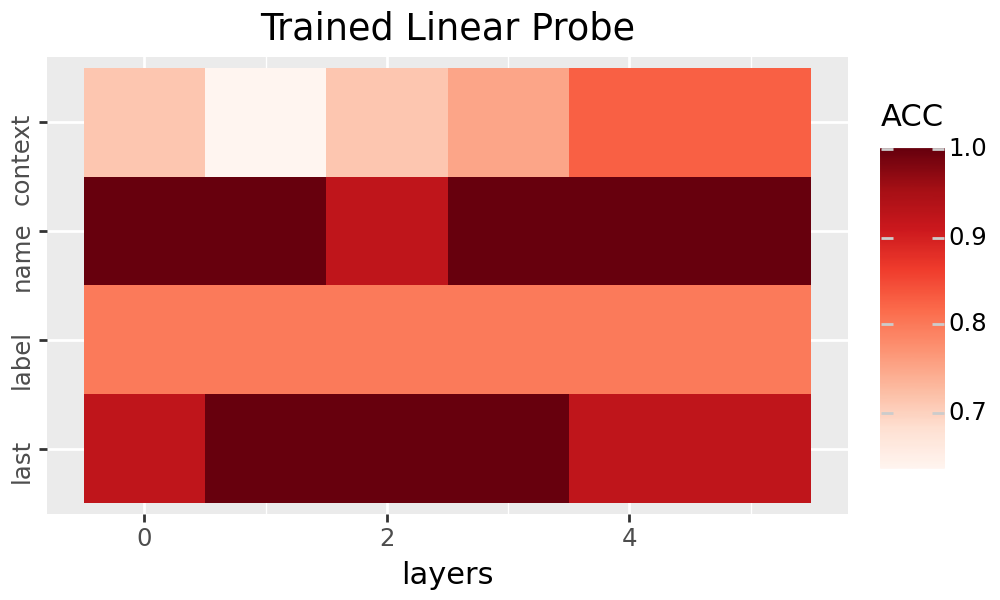

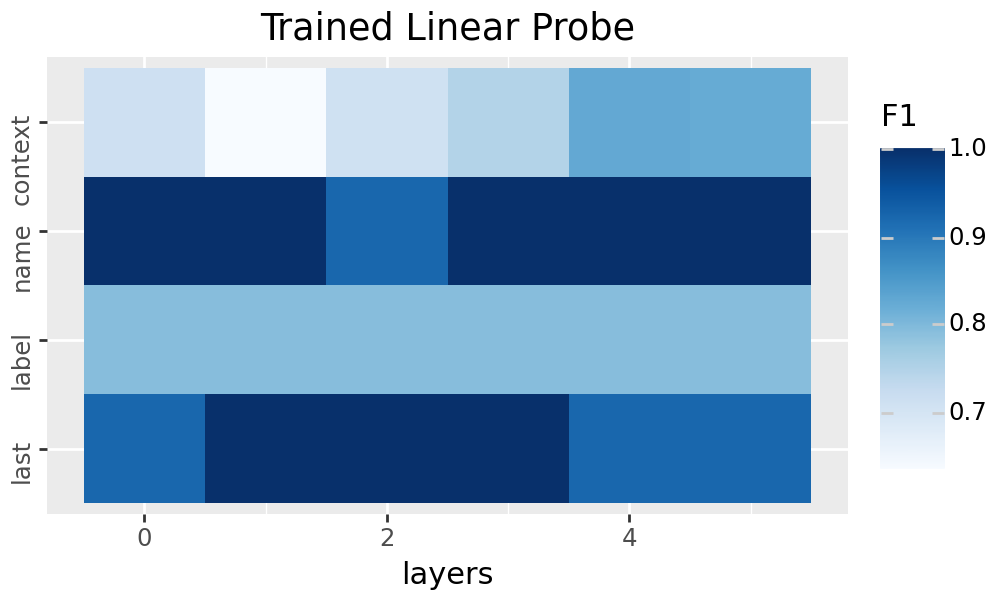

In [ ]:
plot_results(mt_stats)

### Colors

In [79]:
cl_context = ['is']
cl_trainset = generate_doable_examples(colors["train"], gpt160, tokenizer160, colors_label_mapping, cl_context, n=70) \
    + generate_doable_examples(colors["validation"], gpt160, tokenizer160, colors_label_mapping, cl_context, n=30)
cl_testset = generate_doable_examples(colors["test"], gpt160, tokenizer160, colors_label_mapping, cl_context, n=50)

len(cl_trainset), len(cl_testset)

(115, 64)

In [80]:
cl_stats = train_probe(gpt160, tokenizer160, colors_label_mapping, cl_trainset, cl_testset)

layer: 0, position: last


100%|██████████| 64/64 [00:01<00:00, 59.17it/s]


acc: 89.062%, f1: 0.891
layer: 0, position: label


100%|██████████| 64/64 [00:01<00:00, 55.88it/s]


acc: 86.719%, f1: 0.867
layer: 0, position: name


...

acc: 83.594%, f1: 0.835
layer: 11, position: name


100%|██████████| 64/64 [00:01<00:00, 59.63it/s]


acc: 90.625%, f1: 0.906
layer: 11, position: context


100%|██████████| 64/64 [00:01<00:00, 57.14it/s]

acc: 64.844%, f1: 0.645


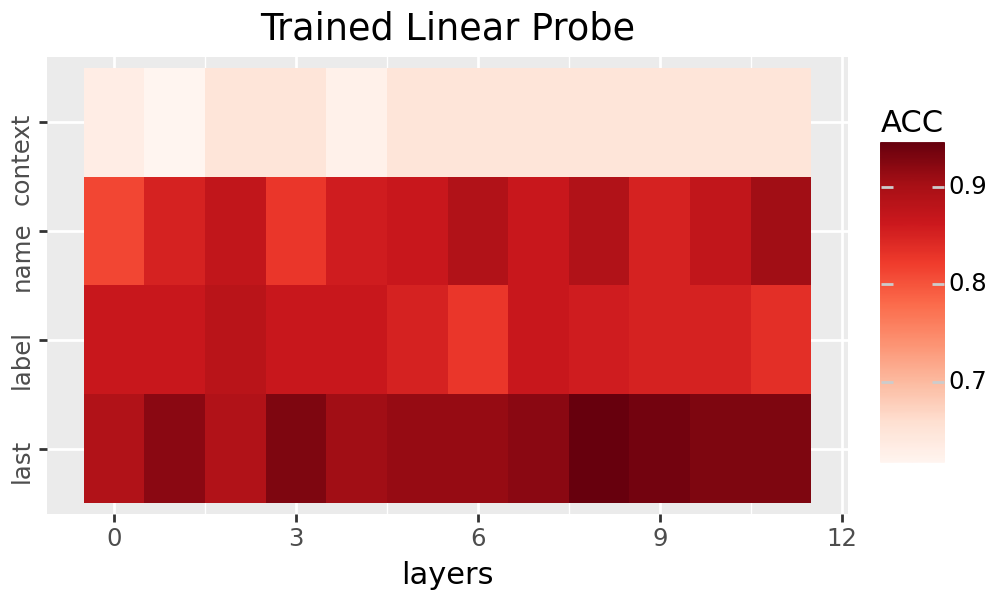

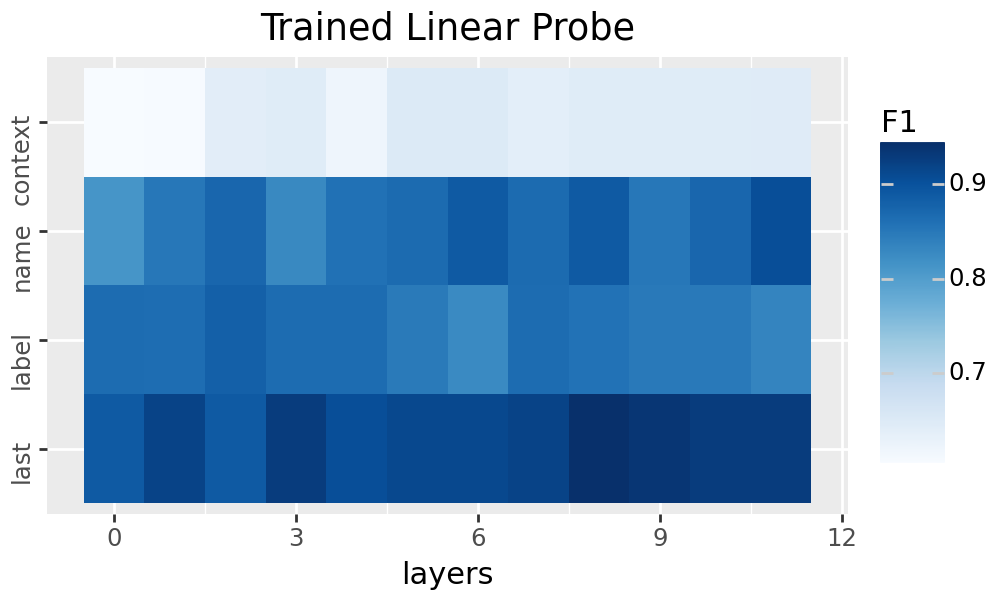

In [83]:
plot_results(cl_stats)